# 06 — Observer frame vs. velocity frame

**Exploratory twin of `scripts/plot_velocity_frame_comparison.py`.** Both this
notebook and that script call the same stage functions from
`dvcorr.pipeline.velocity_frame_comparison` — the single source of truth for
this pipeline (CLAUDE.md: notebooks are exploration only, "diagnostics that
import the real modules, never reimplement them"). Every code cell below just
calls one stage in sequence.

## The question

Notebook 05 measured the **observer-frame** dipole ζ₁ (Nusser 2017 eq. 23–24):
each velocity object α sits at the center of its shells, axed on
n̂_V,α = observer → s_α, weighted by the only thing a peculiar-velocity survey
can actually measure — the **radial** speed u_α = v_α · n̂_V,α.

This notebook adds the **velocity-frame** variant, which removes the observer
from the statistic entirely. For each center it uses that center's own flow
direction as the axis and its full speed as the scalar:

$$\hat z_\alpha = \frac{\mathbf v_\alpha}{|\mathbf v_\alpha|}, \qquad
  \text{scalar} = |\mathbf v_\alpha| \quad\text{(not } u_\alpha\text{)}$$

The observer survives only in two places, neither of which touches the
statistic: the `core_center_mask` candidate cut (pure geometry, deliberately
**the identical function for both frames**) and the diagnostic angle δ_α below.

**Comparing the two quantifies what is lost by having a finite-distance
observer restricted to radial velocities.** In the ideal spherical-infall,
distant-observer limit the two coincide; their divergence measures projection
geometry plus the center's own bulk motion.

## Reading an amplitude gap — three contributors, not one

A difference between the two curves is **not** purely axis rotation. In
decreasing order of size on the toy infall configuration:

1. **Self-alignment / no ⟨cos²θ⟩ = 1/3 dilution.** The velocity frame picks its
   axis from the same object that supplies the scalar, so the alignment is not
   averaged down over the shell. Worth a factor ≈ 3 on the sign-gate toy.
2. **|v| vs. v · n̂_V.** A positive-definite scalar replacing a signed,
   generally smaller one.
3. **Axis rotation** proper — the transverse velocity component, invisible to
   the observer frame.

Do not attribute the whole gap to (3).

## Sign

Both frames are **positive** for coherent infall. Mass flows toward
overdensities, so the density excess lies *ahead* of the flow (velocity frame),
and ζ_ℓ = (−1)^ℓ ξ_Tu,ℓ flips hard rule 2's negative group-centered ξ_Tu,1 to a
positive ζ₁ (observer frame). A **negative** dipole from either frame on an
infall configuration is an orientation bug, not a result — see the sign gate in
`tests/test_velocity_frame_dipole.py`.

In [1]:
%matplotlib inline

import numpy as np

from dvcorr import conventions
from dvcorr.config import PathsConfig
from dvcorr.estimators.shell_dipole import expected_shell_occupancy
from dvcorr.pipeline.velocity_centered import global_number_density, load_and_carve, draw_candidates
from dvcorr.pipeline.velocity_frame_comparison import (
    ComparisonRunConfig,
    select_shared_centers,
    run_both_frames,
    normalize_comparison,
    make_comparison_figure,
    make_angle_diagnostic_figure,
)

print("observer (box center):", conventions.OBSERVER_POSITION)
print("BOX_SIZE            :", conventions.BOX_SIZE, " h^-1 Mpc")
print("MAX_ANALYSIS_RADIUS :", conventions.MAX_ANALYSIS_RADIUS, " h^-1 Mpc")

observer (box center): [500. 500. 500.]
BOX_SIZE            : 1000.0  h^-1 Mpc
MAX_ANALYSIS_RADIUS : 500.0  h^-1 Mpc


## Parameters

`ComparisonRunConfig` extends notebook 05's `RunConfig` with the comparison-only
knobs (the two output filenames and `axis_null_seed`); everything else —
`sub_volume_radius`, the composed `cfg.shells` binning, `n_candidate_centers`,
the seeds — is inherited unchanged, so this run is directly comparable to 05's.

`min_center_speed` lives on the **base** `RunConfig` because it filters the
*shared* center set, not one frame's: a halo with |v_α| below it has no
well-defined flow direction v̂_α, so it is dropped from **both** frames at the
orchestration level, never inside an estimator.

In [2]:
cfg = ComparisonRunConfig()
paths = PathsConfig()
observer = np.asarray(conventions.OBSERVER_POSITION, dtype=float)

print(cfg)
print()
print("shell_edges      :", cfg.shells.shell_edges)
print("min_center_speed :", cfg.min_center_speed, "km/s")
print("axis_null_seed   :", cfg.axis_null_seed)

ComparisonRunConfig(sub_volume_radius=300.0, shells=ShellConfig(min_radius=5.0, max_radius=60.0, radii_step=5.0, sigma_star=250.0), n_candidate_centers=4000, seed=42, shuffle_seed=43, output_name='velocity_centered_dipole.png', dpi=150, min_center_speed=1.0, comparison_output_name='velocity_frame_comparison.png', angle_diagnostic_output_name='velocity_frame_angle_diagnostic.png', axis_null_seed=44)

shell_edges      : [ 5. 10. 15. 20. 25. 30. 35. 40. 45. 50. 55. 60.]
min_center_speed : 1.0 km/s
axis_null_seed   : 44


## 1 — Load and carve

Identical stage to notebook 05 — `load_and_carve` is *imported from*
`dvcorr.pipeline.velocity_centered`, not duplicated here. Loads only
`POSITION_COLUMNS + VELOCITY_COLUMNS` from the ~4M-row MDPL2 catalog, then keeps
halos within `cfg.sub_volume_radius` of the observer. Plain Euclidean distance
IS the minimum image here — the sub-volume sits well inside the box, clear of
the periodic faces — so no wrapping is needed (hard rule 3 is discharged by the
carve, not by the geometry primitives).

In [3]:
pos, vel = load_and_carve(cfg, paths)

loading /home/ofeke2000/Cross-correlating-Tempel-SDSS-groups-with-Cosmicflows-4-peculiar-velocities/data/mdpl2_rockstar_125_pid-1_mvir12.csv (columns: ['x', 'y', 'z', 'vx', 'vy', 'vz']) ...


loaded 4093751 halos


carved 464764 of 4093751 halos within sub_volume_radius = 300.0 h^-1 Mpc (11.35%)


## 2 — Draw candidate centers

A seeded subsample of the carved halos, as *candidate* centers. Two cuts still
stand between these and the measured center set — the core cut and the speed
floor — and the next cell applies both, once, for both frames.

In [4]:
s_candidates, v_candidates = draw_candidates(cfg, pos, vel)
print("candidate centers:", s_candidates.shape[0])

candidate centers: 4000


## 3 — Select the SHARED center set

This is the cell that makes the comparison a fair one. `select_shared_centers`
applies, **once**:

1. `core_center_mask` — the same function the observer-frame estimator uses
   internally, with `core_margin = r_max`, so a surviving center's full shell
   fits inside the carved sub-volume (suppressing the boundary-truncation bias);
2. the `min_center_speed` floor — centers whose flow direction is ill-defined.

Both frames then receive the **identical** `s_centers` / `v_centers` arrays, so
the only difference between the two measurements is the axis and the velocity
scalar. `n_dropped_slow` is returned as a field, not merely printed.

In [5]:
centers = select_shared_centers(cfg, s_candidates, v_candidates, observer)

print()
print("n_candidates   :", centers.n_candidates)
print("n_core         :", centers.n_core, " (survived the core cut)")
print("n_dropped_slow :", centers.n_dropped_slow, f" (|v| < {cfg.min_center_speed} km/s)")
print("n_centers      :", centers.n_centers, " <- used by BOTH frames")

speeds = np.linalg.norm(centers.v_centers, axis=1)
print()
print(f"center speeds  : min={speeds.min():.1f}  median={np.median(speeds):.1f}  max={speeds.max():.1f} km/s")

n_candidates = 4000 -> core cut -> n_core = 2031 (50.8% survive) -> speed floor (min_center_speed = 1.0 km/s) -> n_centers = 2031 (0 dropped as too slow)

n_candidates   : 4000
n_core         : 2031  (survived the core cut)
n_dropped_slow : 0  (|v| < 1.0 km/s)
n_centers      : 2031  <- used by BOTH frames

center speeds  : min=28.3  median=471.0  max=1928.1 km/s


## 4 — Run both frames, plus the random-axis null

`run_both_frames` calls `velocity_centered_shell_dipole` and
`velocity_frame_shell_dipole` on those same arrays, then runs the null. Because
both estimators re-apply the identical (now idempotent, order-preserving)
`core_center_mask`, their per-center arrays are **row-aligned** — the stage
asserts that explicitly.

### Why the velocity frame needs a *random-axis* null

The observer-frame null permutes u_α among centers. That works there only
because ⟨u_α⟩ ≈ 0 across centers, so the permuted stack collapses.

The velocity-frame dipole is **self-aligned**: the axis is chosen from the same
object whose velocity supplies the scalar. Permuting |v_α| leaves every center's
axis–density alignment intact, and since |v| is positive-definite the permuted
stack retains N·⟨|v|⟩·⟨A⟩ — measured at **185% of the signal** on a synthetic
mock, i.e. no null at all. Randomizing the **axis** (same speeds, same
positions, isotropic v̂) is the guard against that align-then-measure bias, and
it does collapse. It costs one extra estimator pass; that is deliberate.

In [6]:
results = run_both_frames(cfg, centers, pos, observer)

obs_result, vel_result = results.obs_result, results.vel_result
print()
print("obs n_centers :", obs_result.n_centers)
print("vel n_centers :", vel_result.n_centers)

# Occupancy is pure geometry and cannot depend on the axis: a strong invariant.
same_occupancy = np.array_equal(obs_result.per_center_count, vel_result.per_center_count)
print("per-center occupancy identical across frames:", same_occupancy)


obs n_centers : 2031
vel n_centers : 2031
per-center occupancy identical across frames: True


## 5 — Normalize both frames

`global_number_density` gives n̄ over the sub-volume; `normalize_comparison`
turns both raw results + n̄ into the plotted curves via the shared
`normalize_stacked_dipole` (one home for the ζ̂₁ = 3·(dipole/N_c)/(√(3/4π)·n̄V_b)
arithmetic), and additionally builds the per-center decomposition the angle
diagnostic needs: each center's own normalized curve, shell-averaged, differenced
between frames.

In [7]:
n_bar = global_number_density(pos.shape[0], cfg.sub_volume_radius)
comparison = normalize_comparison(cfg, results, n_bar)

print(f"n_bar = {n_bar:.5f} halos per (h^-1 Mpc)^3")
print()
print("r_cen           :", np.round(comparison.shell_centers, 1))
print("zeta_hat  (obs) :", np.round(comparison.obs.zeta_hat, 2))
print("zeta_hat  (vel) :", np.round(comparison.vel.zeta_hat, 2))
print("null      (obs) :", np.round(comparison.obs.zeta_hat_shuffle, 2))
print("null      (vel) :", np.round(comparison.vel.zeta_hat_shuffle, 2))
print("monopole  (obs) :", np.round(comparison.obs.monopole_norm, 2))
print("monopole  (vel) :", np.round(comparison.vel.monopole_norm, 2))

n_bar = 0.00411 halos per (h^-1 Mpc)^3

r_cen           : [ 7.5 12.5 17.5 22.5 27.5 32.5 37.5 42.5 47.5 52.5 57.5]
zeta_hat  (obs) : [144.18 104.71  84.35  65.07  54.1   44.3   38.71  30.76  26.7   23.56
  19.47]
zeta_hat  (vel) : [423.21 315.85 247.62 202.81 166.03 146.52 125.5  106.62  93.96  83.76
  70.62]
null      (obs) : [-3.68  2.49  0.37  0.92 -5.29 -3.02 -0.75 -2.33 -0.77  0.29  1.03]
null      (vel) : [-5.38 -8.34 -2.09 -1.07  1.37 -1.52  2.65  1.18  0.73  1.5  -0.94]
monopole  (obs) : [-19.85 -11.77  -9.48  -7.09  -4.61  -3.68  -3.01  -2.53  -2.34  -2.55
  -1.99]
monopole  (vel) : [799.43 647.06 581.85 553.89 539.7  526.09 517.56 512.96 512.14 509.51
 506.41]


## 6 — The comparison figure

**Top panel:** ζ̂₁ for both frames, each with its across-center standard-error
band and its own null.

**Bottom panel (the ℓ = 0 companion, hard rule 6 — the dipole is never plotted
alone):** the two monopoles on **twin y-axes**. The velocity-frame monopole sits
at ≈⟨|v|⟩ (hundreds of km/s) rather than at zero, because |v| is
positive-definite and cannot cancel the way u does — a shared axis would squash
the near-zero observer-frame curve into invisibility, hence the twin axes.

**Both curves decline steeply at small r, and that is not the diagnostic.** Each
monopole is its mean scalar times the occupancy ratio, which on a clustered
field *is* 1 + ξ_hh(r) — measured here falling 1.46 → 1.005 over these shells.
Both frames inherit that shape from halo clustering alone. Flatness is what an
unclustered Poisson field would give, not this one.

The frames separate only once that shared factor is divided out, and *that* is
the finite-distance story:

| after dividing out 1+ξ_hh | r = 7.5 → 57.5 | asymptote | reading |
|---|---|---|---|
| observer frame | −13.6 → −2.7 km/s | ⟨u⟩ = −2.67 | **trend survives** = (2r/3R) leakage |
| velocity frame | 546.7 → 504.0 km/s | ⟨\|v\|⟩ = 504.5 | **flat to ~8%** — no R, no leakage |

The velocity frame's residual ~8% rise at small r is not leakage either: it is a
genuine speed–density correlation (fast halos live in denser environments), one
of the two things — with shell incompleteness — a velocity-frame monopole
residual can legitimately mean.

⚠️ **The SEM bands treat centers as independent, which they are not** — centers
closer together than a shell radius share tracers, so the bands understate the
true uncertainty, more so at large r. These are "how noisy is the stack"
diagnostics, not calibrated confidence intervals. Mock covariance (the
not-yet-built `mocks/` arm) is the real fix.

wrote /home/ofeke2000/Cross-correlating-Tempel-SDSS-groups-with-Cosmicflows-4-peculiar-velocities/output/velocity_frame_comparison.png


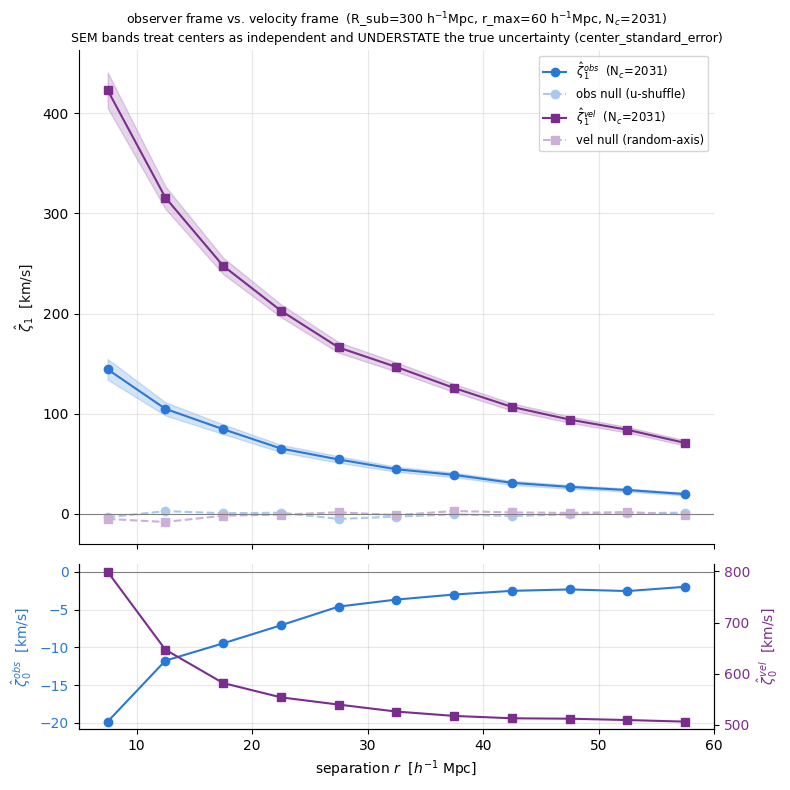

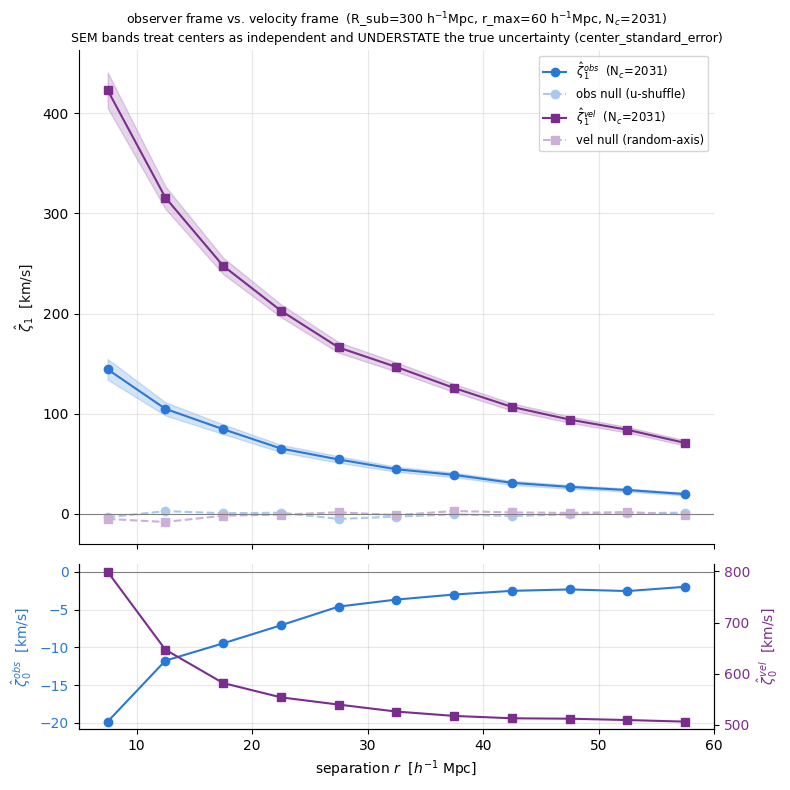

In [8]:
fig = make_comparison_figure(cfg, results, comparison)

paths.ensure_output_dir()
out_path = paths.output_dir / cfg.comparison_output_name
fig.savefig(out_path, dpi=cfg.dpi, bbox_inches="tight")
print(f"wrote {out_path}")

fig

## 7 — Where does the gap between the frames come from?

δ_α = arccos(v̂_α · n̂_V,α) is the angle between the two frames' axes for each
center — the only place the observer enters the per-center bookkeeping, and a
pure diagnostic.

**Top panel** bins the per-center dipole difference (ζ̂₁^vel − ζ̂₁^obs, each
center's own curve shell-averaged) by δ_α:

- a **few high-δ_α centers driving the gap** ⇒ bulk-flow contamination;
- a **smooth spread** ⇒ genuine projection geometry.

**Bottom panel** is the δ_α histogram against the isotropic expectation
P(δ) ∝ sin δ (what randomly oriented flow directions would give). An **excess at
low δ** relative to that reference means flow directions align with the lines of
sight — residual bulk motion of the sample.

Note δ_α ≈ 0 *and* δ_α ≈ π both mean the axes are collinear: for a purely radial
flow the axis flip and the u → |v| sign flip cancel exactly, so the frames agree
regardless of direction. They can only diverge through the **transverse**
velocity component.

wrote /home/ofeke2000/Cross-correlating-Tempel-SDSS-groups-with-Cosmicflows-4-peculiar-velocities/output/velocity_frame_angle_diagnostic.png


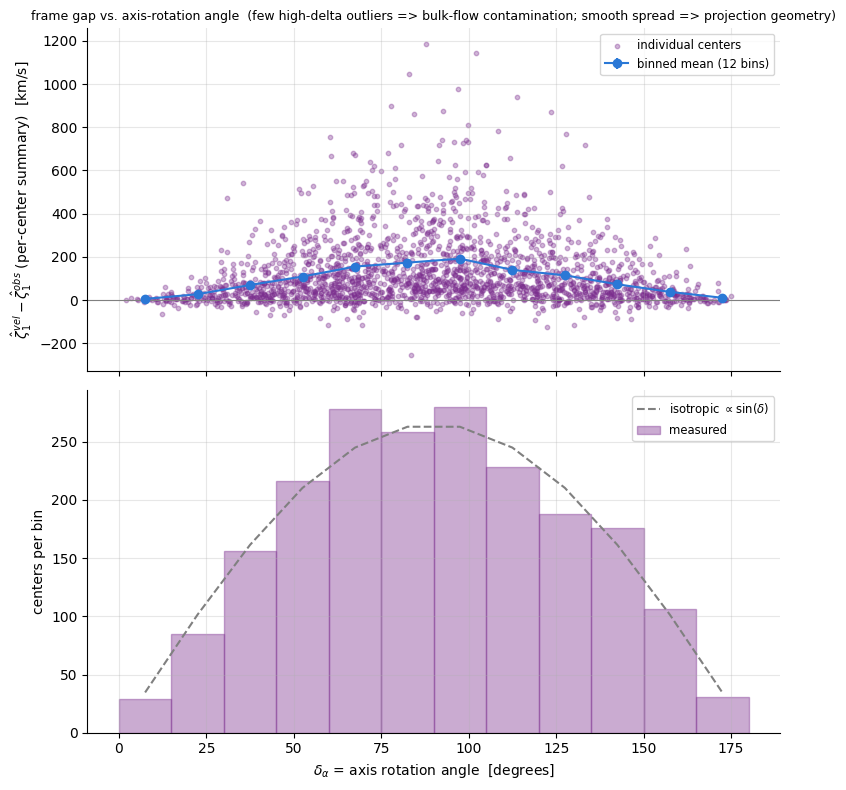

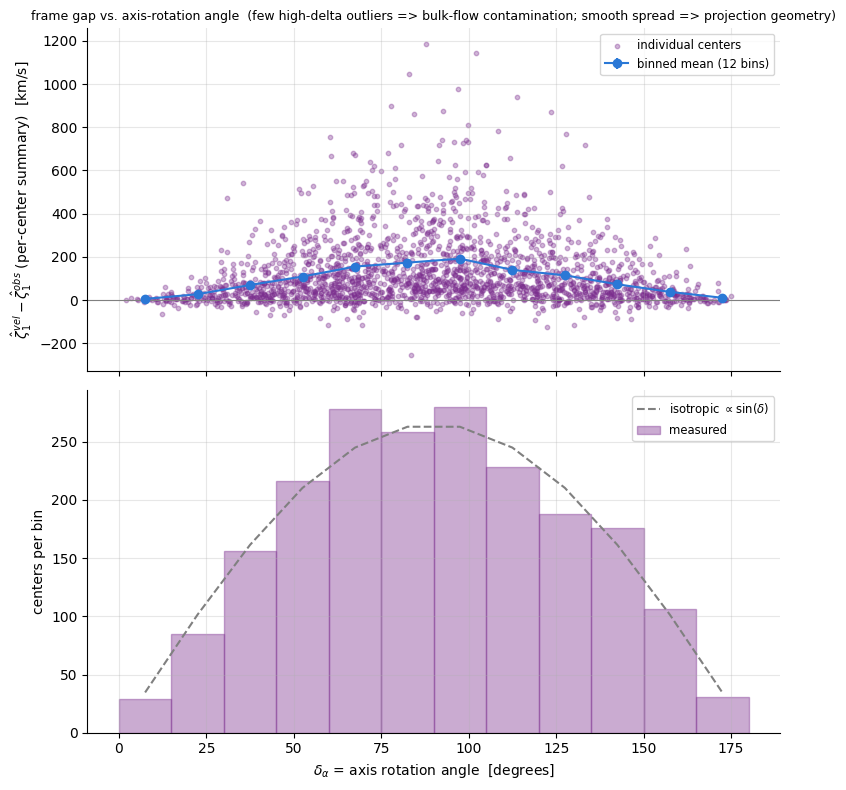

In [9]:
fig_angle = make_angle_diagnostic_figure(cfg, comparison)

out_path_angle = paths.output_dir / cfg.angle_diagnostic_output_name
fig_angle.savefig(out_path_angle, dpi=cfg.dpi, bbox_inches="tight")
print(f"wrote {out_path_angle}")

fig_angle

## 8 — Summary numbers

A compact read-out of the comparison: the shell-averaged amplitude of each
frame, the ratio between them, and how far each null sits from zero in units of
its own SEM.

In [10]:
delta_deg = np.degrees(comparison.per_center_delta)

print(f"N_c = {centers.n_centers} centers, {len(comparison.shell_centers)} shells "
      f"({comparison.shell_centers[0]:.1f} - {comparison.shell_centers[-1]:.1f} h^-1 Mpc)")
print()
print(f"shell-averaged |zeta_hat|  obs : {np.abs(comparison.obs.zeta_hat).mean():8.2f} km/s")
print(f"shell-averaged |zeta_hat|  vel : {np.abs(comparison.vel.zeta_hat).mean():8.2f} km/s")
print(f"                     vel / obs : {np.abs(comparison.vel.zeta_hat).mean() / np.abs(comparison.obs.zeta_hat).mean():8.2f}")
print()
print(f"null / SEM  obs (u-shuffle)   : {np.nanmean(np.abs(comparison.obs.zeta_hat_shuffle) / comparison.obs.sem):8.2f}")
print(f"null / SEM  vel (random-axis) : {np.nanmean(np.abs(comparison.vel.zeta_hat_shuffle) / comparison.vel.sem):8.2f}")
print("   (both should be O(1) if the nulls are flat)")
print()
# The monopole panel, with halo clustering divided out. Both raw monopoles are
# (mean scalar) x (occupancy ratio), and that ratio IS 1 + xi_hh(r) -- so both
# decline from clustering alone. What distinguishes the frames is the residual.
occupancy = obs_result.pair_count / (obs_result.n_centers * expected_shell_occupancy(n_bar, obs_result.shell_edges))
print("occupancy ratio 1+xi_hh(r) :", np.round(occupancy, 3))
print()
print("monopole, raw               obs:", np.round(comparison.obs.monopole_norm, 1))
print("                            vel:", np.round(comparison.vel.monopole_norm, 1))
print("monopole / (1+xi_hh)        obs:", np.round(comparison.obs.monopole_norm/occupancy, 1),
      "  <- TREND SURVIVES = finite-distance leakage")
print("                            vel:", np.round(comparison.vel.monopole_norm/occupancy, 1),
      "  <- FLAT: no R, no leakage")
print(f"                asymptotes: <u> = {obs_result.per_center_u.mean():.2f} km/s, "
      f"<|v|> = {vel_result.per_center_speed.mean():.1f} km/s")
print()
print(f"delta_alpha : median {np.median(delta_deg):.1f} deg, "
      f"{(delta_deg < 30).sum()} centers below 30 deg, {(delta_deg > 150).sum()} above 150 deg")
print(f"per-center dipole difference : mean {comparison.per_center_dipole_difference.mean():+.2f} km/s")

N_c = 2031 centers, 11 shells (7.5 - 57.5 h^-1 Mpc)

shell-averaged |zeta_hat|  obs :    57.81 km/s
shell-averaged |zeta_hat|  vel :   180.23 km/s
                     vel / obs :     3.12

null / SEM  obs (u-shuffle)   :     0.61
null / SEM  vel (random-axis) :     0.38
   (both should be O(1) if the nulls are flat)

occupancy ratio 1+xi_hh(r) : [1.462 1.204 1.107 1.063 1.043 1.023 1.012 1.007 1.009 1.008 1.005]

monopole, raw               obs: [-19.8 -11.8  -9.5  -7.1  -4.6  -3.7  -3.   -2.5  -2.3  -2.6  -2. ]
                            vel: [799.4 647.1 581.9 553.9 539.7 526.1 517.6 513.  512.1 509.5 506.4]
monopole / (1+xi_hh)        obs: [-13.6  -9.8  -8.6  -6.7  -4.4  -3.6  -3.   -2.5  -2.3  -2.5  -2. ]   <- TREND SURVIVES = finite-distance leakage
                            vel: [546.7 537.4 525.6 520.9 517.6 514.1 511.6 509.4 507.5 505.3 504. ]   <- FLAT: no R, no leakage
                asymptotes: <u> = -2.67 km/s, <|v|> = 504.5 km/s

delta_alpha : median 89.7 deg, 114 cen